# Wind Power Forecasting 



## 0 · Setup & Imports

In [4]:
!pip install lightgbm 
#scikit-learn torch numpy pandas matplotlib seaborn PyEMD

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 2.8 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.0 MB/s  0:00:01


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Libraries loaded ✓')

Libraries loaded ✓



## 1 · Load Raw Data

In [2]:
DATA_DIR = Path('./data')

# df_1: production (site_name, delivery_time, production [MW], installed_capacity [MW])
# df_2: site coordinates (site_name, latitude, longitude)
# df_3: weather NWP IFS-HRES 9km (site_name, delivery_time, 21 meteo vars)
df_1 = pd.read_parquet(DATA_DIR / 'dataset_1.parquet')
df_2 = pd.read_parquet(DATA_DIR / 'dataset_2.parquet')
df_3 = pd.read_parquet(DATA_DIR / 'dataset_3.parquet')

# Ensure tz-aware datetime
for df in [df_1, df_3]:
    df['delivery_time'] = pd.to_datetime(df['delivery_time'], utc=True)

print(f'df_1 (production): {df_1.shape}   |  sites: {df_1.site_name.nunique()}')
print(f'df_2 (locations) : {df_2.shape}')
print(f'df_3 (weather)   : {df_3.shape}')
print(f'\nProduction date range: {df_1.delivery_time.min()} → {df_1.delivery_time.max()}')
print(f'Weather date range  : {df_3.delivery_time.min()} → {df_3.delivery_time.max()}')

df_1 (production): (274800, 4)   |  sites: 10
df_2 (locations) : (10, 3)
df_3 (weather)   : (275280, 23)

Production date range: 2022-12-31 23:00:00+00:00 → 2026-02-18 22:00:00+00:00
Weather date range  : 2023-01-01 00:00:00+00:00 → 2026-02-20 23:00:00+00:00


## 2 · Data Cleaning & Target Engineering

In [4]:
#  Missing values
print('=== Missing values ===')
print(df_1.isnull().sum())

# Only production has 96 NaNs → interpolate linearly per site (short gaps)
df_1 = df_1.sort_values(['site_name', 'delivery_time'])
df_1['production'] = (
    df_1.groupby('site_name')['production']
    .transform(lambda s: s.interpolate(method='linear', limit=4))
)
print(f'\nNaN in production after interpolation: {df_1.production.isna().sum()}')

=== Missing values ===
site_name              0
delivery_time          0
production            80
installed_capacity     0
dtype: int64

NaN in production after interpolation: 64


In [5]:
#  Target: capacity factor ∈ [0, 1]
# CF = production / installed_capacity  →  physically bounded in [0, 1]
df_1['capacity_factor'] = df_1['production'] / df_1['installed_capacity']

# Sanity check: clip any tiny numerical artefacts outside [0, 1]
anomalies = df_1[(df_1.capacity_factor < 0) | (df_1.capacity_factor > 1.01)]
print(f'CF outside [0, 1.01]: {len(anomalies)} rows → clipping')
df_1['capacity_factor'] = df_1['capacity_factor'].clip(0, 1)

df_1[['site_name', 'delivery_time', 'production', 'installed_capacity', 'capacity_factor']].head(3)

CF outside [0, 1.01]: 0 rows → clipping


,site_name,delivery_time,production,installed_capacity,capacity_factor
164880,Belwind Phase 1,2022-12-31 23:00:00+00:00,148.2250,171.0000,0.8668
164881,Belwind Phase 1,2023-01-01 00:00:00+00:00,147.7025,171.0000,0.8638
164882,Belwind Phase 1,2023-01-01 01:00:00+00:00,146.1775,171.0000,0.8548


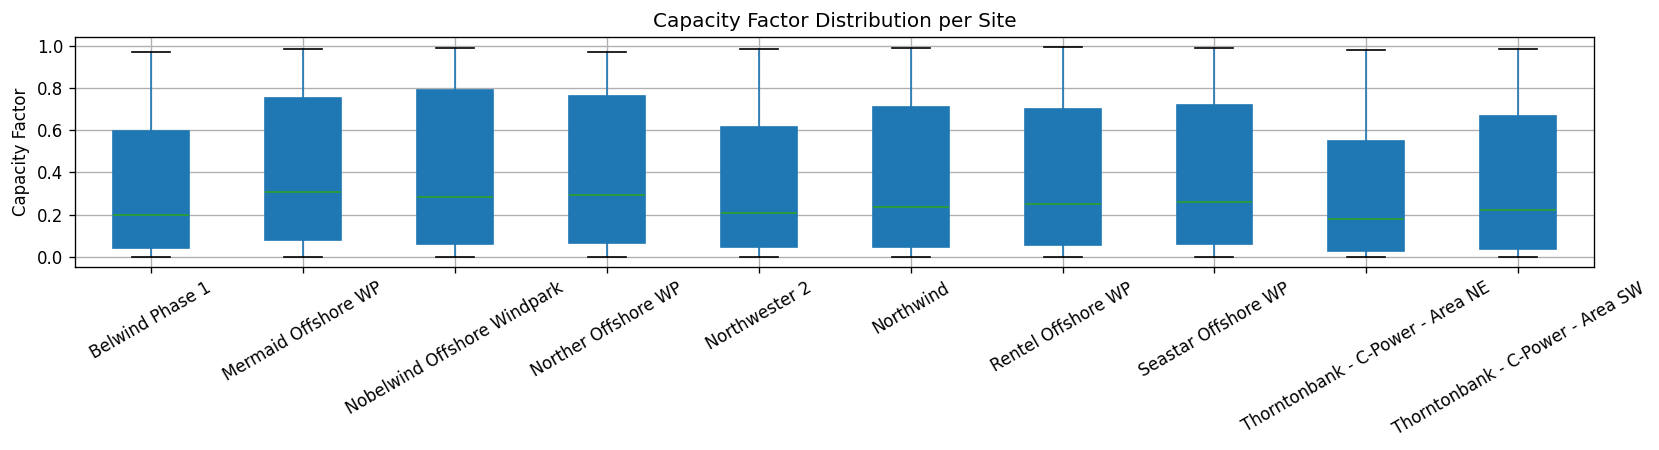

In [6]:
#   Capacity factor distribution per site 
fig, ax = plt.subplots(figsize=(14, 4))
order = df_1.groupby('site_name')['capacity_factor'].median().sort_values(ascending=False).index
df_1.boxplot(column='capacity_factor', by='site_name', ax=ax,
             vert=True, patch_artist=True, rot=30)
ax.set_title('Capacity Factor Distribution per Site')
ax.set_xlabel('')
ax.set_ylabel('Capacity Factor')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 3 · Weather Processing
> **Rule**: keep only the latest available forecast for each (site, hour) → the closest forecast run to actual observations.

In [7]:
#  Keep latest forecast run per (site, delivery_time)

# df_3 from Open-Meteo Historical Forecast API may contain multiple runs per hour.
# Strategy: sort by delivery_time and keep the last entry per (site, hour).
# If a 'forecast_run' or 'model_run_time' column exists, use it directly.

if 'forecast_run' in df_3.columns:
    df_weather = (
        df_3.sort_values('forecast_run')
        .groupby(['site_name', 'delivery_time'], as_index=False)
        .last()
    )
else:
    # No explicit run column → assume file is already ordered by run; keep last duplicate
    df_weather = (
        df_3.sort_values('delivery_time')
        .drop_duplicates(subset=['site_name', 'delivery_time'], keep='last')
    )

print(f'Weather rows after dedup: {len(df_weather)}  (was {len(df_3)})')

Weather rows after dedup: 275280  (was 275280)


In [8]:
#  Derived wind features 

# Wind power is ~proportional to v³ → add cubic transforms at hub height (100m)
df_weather['wind_power_density'] = 0.5 * 1.225 * df_weather['wind_speed_100m'] ** 3  # W/m²

# Wind components (for direction-aware models)
angle_100 = np.deg2rad(df_weather['wind_direction_100m'])
df_weather['wind_u_100m'] = -df_weather['wind_speed_100m'] * np.sin(angle_100)
df_weather['wind_v_100m'] = -df_weather['wind_speed_100m'] * np.cos(angle_100)

angle_10 = np.deg2rad(df_weather['wind_direction_10m'])
df_weather['wind_u_10m'] = -df_weather['wind_speed_10m'] * np.sin(angle_10)
df_weather['wind_v_10m'] = -df_weather['wind_speed_10m'] * np.cos(angle_10)

# Wind shear exponent (power law: v₁₀₀/v₁₀ = (100/10)^α → α = log(v₁₀₀/v₁₀)/log(10))
ratio = (df_weather['wind_speed_100m'] + 1e-6) / (df_weather['wind_speed_10m'] + 1e-6)
df_weather['wind_shear_exp'] = np.log(ratio) / np.log(10)

# Relative humidity proxy from dewpoint (Magnus formula)
T = df_weather['temperature_2m']
Td = df_weather['dewpoint_2m']
df_weather['relative_humidity'] = 100 * np.exp((17.625 * Td) / (243.04 + Td)) / np.exp((17.625 * T) / (243.04 + T))

print('Derived features added:', ['wind_power_density','wind_u_100m','wind_v_100m',
                                   'wind_u_10m','wind_v_10m','wind_shear_exp','relative_humidity'])

Derived features added: ['wind_power_density', 'wind_u_100m', 'wind_v_100m', 'wind_u_10m', 'wind_v_10m', 'wind_shear_exp', 'relative_humidity']



## 4 · Merge & Feature Engineering

In [9]:
# Merge production + weather + coordinates 
df = (
    df_1[df_1['delivery_time'] >= '2023-01-01']  # align with weather start
    .merge(df_weather, on=['site_name', 'delivery_time'], how='left')
    .merge(df_2,       on='site_name',                   how='left')
)
df = df.sort_values(['site_name', 'delivery_time']).reset_index(drop=True)

print(f'Merged dataset: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Merged dataset: (274790, 35)
Missing values:
production         64
capacity_factor    64
dtype: int64


In [10]:
#  Temporal features 
dt = df['delivery_time'].dt

df['hour']       = dt.hour
df['dayofweek']  = dt.dayofweek
df['dayofyear']  = dt.dayofyear
df['month']      = dt.month
df['year']       = dt.year
df['weekofyear'] = dt.isocalendar().week.astype(int)

# Cyclical encoding for circular features
df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['doy_sin']    = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
df['doy_cos']    = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

print('Temporal features added ✓')

Temporal features added ✓


In [11]:
#  Lag & rolling features (per site) 
df = df.sort_values(['site_name', 'delivery_time'])

LAG_HOURS   = [1, 2, 3, 6, 12, 24, 48, 168]  # 1h → 1 week
ROLL_WINDOWS = [6, 24, 168]                    # 6h, 1day, 1week

for lag in LAG_HOURS:
    df[f'cf_lag_{lag}h'] = df.groupby('site_name')['capacity_factor'].shift(lag)

for w in ROLL_WINDOWS:
    roll = df.groupby('site_name')['capacity_factor'].shift(1).rolling(w)
    df[f'cf_roll_mean_{w}h'] = roll.mean().values
    df[f'cf_roll_std_{w}h']  = roll.std().values

# Wind speed lags at hub height
for lag in [1, 3, 6]:
    df[f'ws100_lag_{lag}h'] = df.groupby('site_name')['wind_speed_100m'].shift(lag)

print(f'Dataset shape after lag features: {df.shape}')

Dataset shape after lag features: (274790, 64)


In [12]:
# ── 4.4  Site encoding (for global model strategy)
le = LabelEncoder()
df['site_id'] = le.fit_transform(df['site_name'])
site_id_map = dict(zip(le.classes_, le.transform(le.classes_)))
print('Site ID mapping:', site_id_map)

Site ID mapping: {'Belwind Phase 1': 0, 'Mermaid Offshore WP': 1, 'Nobelwind Offshore Windpark': 2, 'Norther Offshore WP': 3, 'Northwester 2': 4, 'Northwind': 5, 'Rentel Offshore WP': 6, 'Seastar Offshore WP': 7, 'Thorntonbank - C-Power - Area NE': 8, 'Thorntonbank - C-Power - Area SW': 9}



## 5 · Temporal Train / Val / Test Split
> Respect de l'ordre chronologique. Train: 2 ans · Val: 6 mois · Test: 6 mois

Train : 2023-01-08 → 2024-12-31  |  173,394 rows
Val   : 2025-01-01   → 2025-06-30    |  43,440 rows
Test  : 2025-07-01  → 2026-02-18   |  55,910 rows


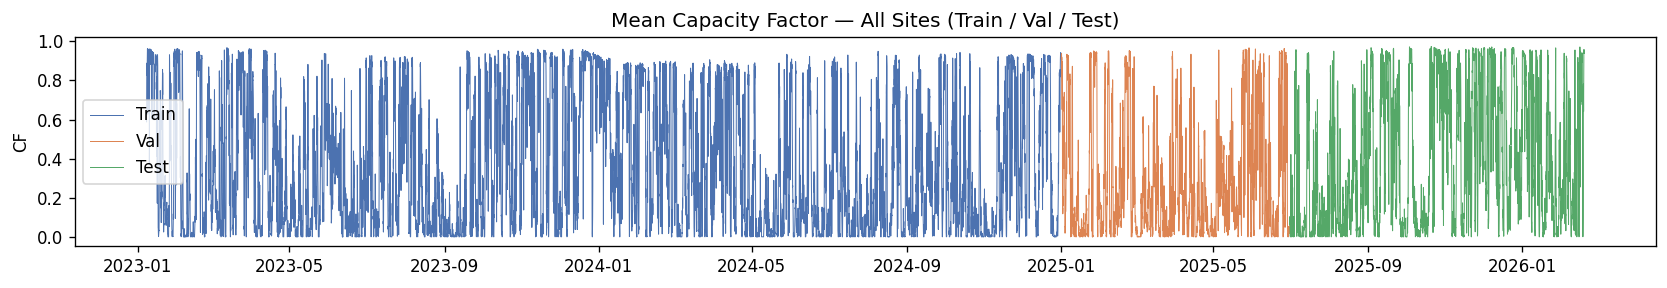

In [13]:
# Data spans Jan 2023 → Feb 2026 (~38 months)
# Allocate: Train Jan 2023 – Dec 2024 | Val Jan–Jun 2025 | Test Jul 2025 – Jan 2026

TRAIN_END = pd.Timestamp('2024-12-31 23:00', tz='UTC')
VAL_END   = pd.Timestamp('2025-06-30 23:00', tz='UTC')

df_train = df[df['delivery_time'] <= TRAIN_END].copy()
df_val   = df[(df['delivery_time'] > TRAIN_END) & (df['delivery_time'] <= VAL_END)].copy()
df_test  = df[df['delivery_time'] > VAL_END].copy()

# Drop rows with NaN lags (beginning of each site's history)
LAG_COLS = [c for c in df.columns if 'lag' in c or 'roll' in c]
df_train.dropna(subset=LAG_COLS, inplace=True)

print(f'Train : {df_train.delivery_time.min().date()} → {df_train.delivery_time.max().date()}  |  {len(df_train):,} rows')
print(f'Val   : {df_val.delivery_time.min().date()}   → {df_val.delivery_time.max().date()}    |  {len(df_val):,} rows')
print(f'Test  : {df_test.delivery_time.min().date()}  → {df_test.delivery_time.max().date()}   |  {len(df_test):,} rows')

# Visualise split
fig, ax = plt.subplots(figsize=(14, 2.5))
for label, grp, color in [('Train', df_train, '#4C72B0'), ('Val', df_val, '#DD8452'), ('Test', df_test, '#55A868')]:
    t = grp.groupby('delivery_time')['capacity_factor'].mean()
    ax.plot(t.index, t.values, color=color, lw=0.6, label=label)
ax.legend()
ax.set_title('Mean Capacity Factor — All Sites (Train / Val / Test)')
ax.set_ylabel('CF')
plt.tight_layout()
plt.show()


## 6 · Metrics Helper

In [15]:
def evaluate(y_true, y_pred, label='Model'):
    """Compute MAE, RMSE, nRMSE (normalised by range of y_true)."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-9)  # range-normalised
    print(f'[{label:30s}]  MAE={mae:.4f}  RMSE={rmse:.4f}  nRMSE={nrmse:.4f}')
    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'nRMSE': nrmse}

results = []  # collect all model results for final comparison


## 7 · Baseline — Persistence Model
> Prédit CF(t) = CF(t-24h)  — référence de bas niveau.

In [16]:
# Simple 24h persistence: CF_pred(t) = CF(t-24h)
# Merge test set with 24h-lagged values
df_test_eval = df_test[['site_name', 'delivery_time', 'capacity_factor', 'cf_lag_24h']].dropna()

res = evaluate(df_test_eval['capacity_factor'], df_test_eval['cf_lag_24h'], label='Persistence 24h')
results.append(res)

[Persistence 24h               ]  MAE=0.2844  RMSE=0.3857  nRMSE=0.3892
